In [1]:
from results_utils import compute_results, plot_results_for_model, load_results_paths, compute_metric
import os
import pandas as pd

%load_ext autoreload
%autoreload 2

In [2]:
metrics = ["norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
bootstrap = 0
random_state = 42

if os.path.exists(f"results_{bootstrap}_{random_state}.csv"):
    df = pd.read_csv(f"results_{bootstrap}_{random_state}.csv", index_col=False)
else:
    df = compute_results(metrics, bootstrap, random_state)
    df.to_csv(f"results_{bootstrap}_{random_state}.csv", index=False)
df.loc[:,[c for c in df.columns if ":" not in c ]]

100%|██████████| 94/94 [14:22<00:00,  9.18s/it]


,dataset,size,num_samples,prompt,n_shots,model,base_method,cal_method,split,norm_error_rate,norm_cross_entropy,ece,cal_loss_bias,norm_min_calibration_bias
0,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,lora,no_calibration,test,0.172 ± 0.034,0.330 ± 0.045,0.032 ± 0.013,11.831 ± 8.132,0.288 ± 0.020
1,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar,test,0.326 ± 0.007,0.532 ± 0.012,0.032 ± 0.009,4.971 ± 2.176,0.506 ± 0.001
2,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,no_calibration,test,0.318 ± 0.000,0.683 ± 0.000,0.176 ± 0.001,25.944 ± 0.086,0.506 ± 0.001
3,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,bias_only,test,0.309 ± 0.007,0.682 ± 0.000,0.186 ± 0.004,25.868 ± 0.091,0.506 ± 0.001
4,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,temp_scaling,test,0.318 ± 0.000,0.521 ± 0.005,0.031 ± 0.012,2.878 ± 0.837,0.506 ± 0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,agnews,256,1024,basic_agnews_0-shot_litgpt,0,lm_tinyllama,lora,no_calibration,test,0.143 ± 0.005,0.228 ± 0.007,0.018 ± 0.007,5.198 ± 2.745,0.216 ± 0.004
90,agnews,256,1024,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar,test,0.273 ± 0.001,0.390 ± 0.001,0.026 ± 0.001,0.151 ± 0.150,0.389 ± 0.000
91,agnews,256,1024,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,no_calibration,test,0.410 ± 0.000,0.991 ± 0.001,0.125 ± 0.000,60.681 ± 0.002,0.389 ± 0.000
92,agnews,256,1024,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,bias_only,test,0.275 ± 0.001,0.405 ± 0.000,0.064 ± 0.001,3.798 ± 0.079,0.389 ± 0.000


In [6]:
df_lora_cal = df.loc[
    (df["base_method"] == "lora_xval") & \
    ((df["cal_method"] == "no_calibration") | \
     (df["cal_method"] == "affine_scalar")  | \
     (df["cal_method"] == "temp_scaling") | \
     (df["cal_method"] == "bias_only")),
    ["dataset", "size", "base_method", "cal_method", "norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
]
# df_results = df.loc[(df["base_method"] != "lora_xval") | (df["cal_method"] != "no_calibration"), :]
df_results = df
df_lora_cal

,dataset,size,base_method,cal_method,norm_error_rate,norm_cross_entropy,ece,cal_loss_bias,norm_min_calibration_bias
10,agnews,8,lora_xval,affine_scalar,0.315 ± 0.080,0.434 ± 0.075,0.049 ± 0.021,24.891 ± 11.307,0.318 ± 0.009
11,agnews,8,lora_xval,no_calibration,0.312 ± 0.086,0.426 ± 0.077,0.047 ± 0.020,23.426 ± 11.225,0.318 ± 0.009
12,agnews,8,lora_xval,bias_only,0.317 ± 0.075,0.432 ± 0.070,0.040 ± 0.022,24.709 ± 10.456,0.318 ± 0.009
13,agnews,8,lora_xval,temp_scaling,0.312 ± 0.086,0.431 ± 0.079,0.052 ± 0.022,24.090 ± 11.483,0.318 ± 0.009
29,dbpedia,4,lora_xval,affine_scalar,0.214 ± 0.034,0.373 ± 0.120,0.122 ± 0.054,81.776 ± 6.004,0.061 ± 0.003
30,dbpedia,4,lora_xval,no_calibration,0.255 ± 0.032,0.683 ± 0.077,0.093 ± 0.029,90.920 ± 1.455,0.061 ± 0.003
31,dbpedia,4,lora_xval,bias_only,0.160 ± 0.035,0.274 ± 0.160,0.034 ± 0.015,70.939 ± 13.604,0.061 ± 0.003
32,dbpedia,4,lora_xval,temp_scaling,0.255 ± 0.032,0.496 ± 0.026,0.173 ± 0.079,87.664 ± 1.204,0.061 ± 0.003
38,dbpedia,2,lora_xval,affine_scalar,0.240 ± 0.032,0.429 ± 0.069,0.145 ± 0.046,79.024 ± 5.814,0.086 ± 0.012
39,dbpedia,2,lora_xval,no_calibration,0.274 ± 0.050,0.785 ± 0.096,0.104 ± 0.037,88.786 ± 2.434,0.086 ± 0.012


In [4]:
df_results.loc[(df_results["dataset"] == "agnews") & (df_results["size"] == 8),[c for c in df_results.columns if ":" not in c ]]

,dataset,size,num_samples,prompt,n_shots,model,base_method,cal_method,split,norm_error_rate,norm_cross_entropy,ece,cal_loss_bias,norm_min_calibration_bias
10,agnews,8,32,basic_agnews_0-shot_litgpt,0,lm_tinyllama,lora,no_calibration,test,0.312 ± 0.086,0.426 ± 0.077,0.047 ± 0.020,23.426 ± 11.225,0.318 ± 0.009
11,agnews,8,32,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar,test,0.320 ± 0.030,0.451 ± 0.033,0.054 ± 0.025,13.280 ± 5.958,0.389 ± 0.000
12,agnews,8,32,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,no_calibration,test,0.410 ± 0.000,0.991 ± 0.001,0.125 ± 0.000,60.681 ± 0.002,0.389 ± 0.000
13,agnews,8,32,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,bias_only,test,0.315 ± 0.038,0.444 ± 0.034,0.055 ± 0.018,11.758 ± 6.221,0.389 ± 0.000
14,agnews,8,32,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,temp_scaling,test,0.410 ± 0.000,0.768 ± 0.018,0.159 ± 0.060,49.270 ± 1.151,0.389 ± 0.000


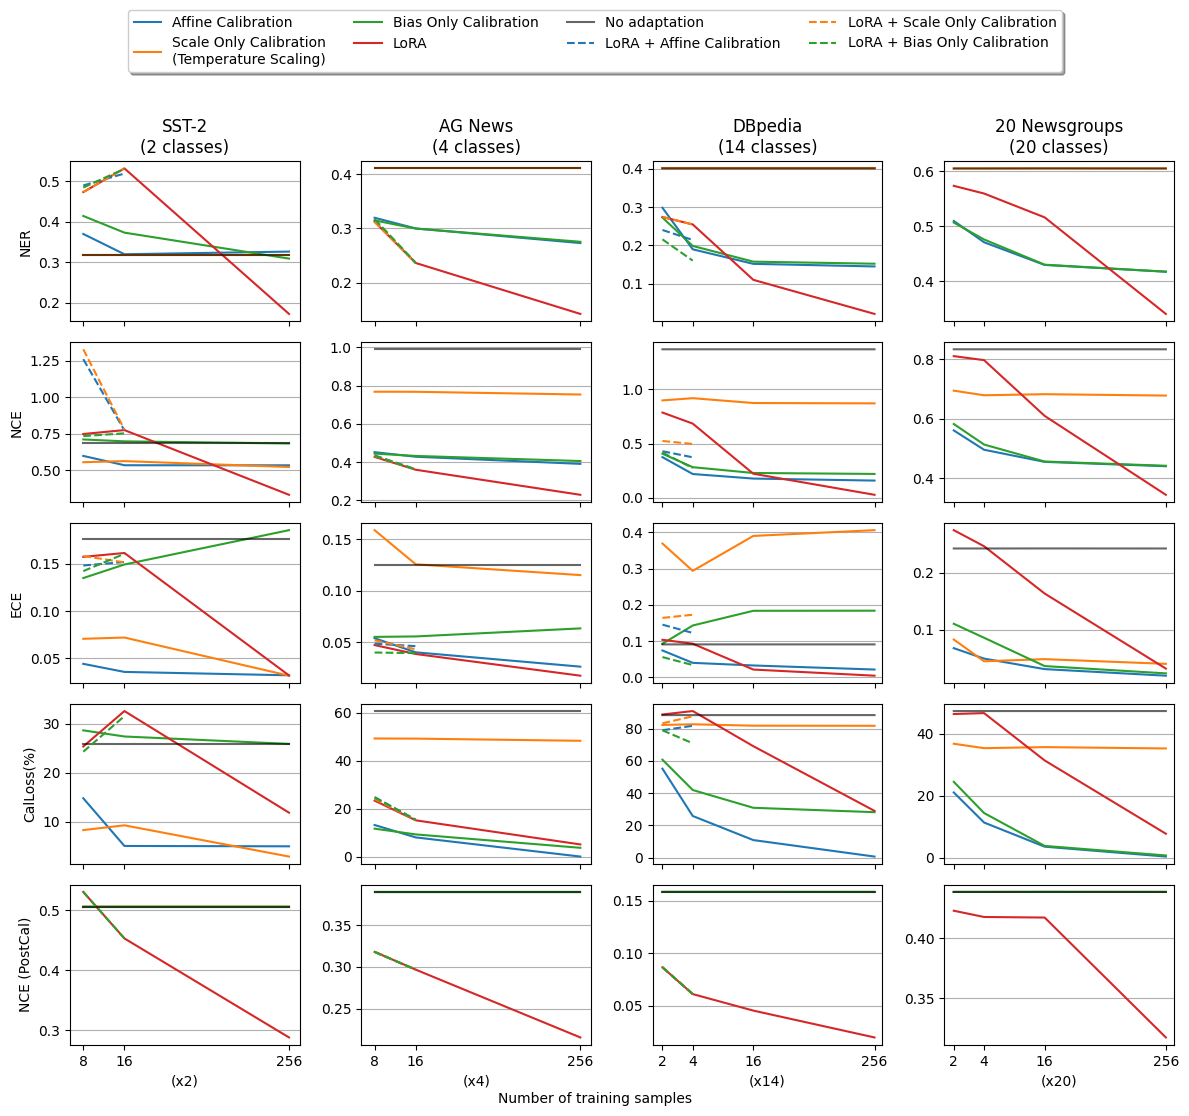

In [11]:
plot_results_for_model(df_results, "lm_tinyllama", metrics, width = 0.5)